In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from dr_kte_adaptive import xMMD2_vsdr_fold_generic
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os

In [129]:
import os
import time
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from scipy.stats import norm  # for Gaussian tail p-values


# =========================
# Data generation utilities
# =========================

def treatment_effect_vector(ns, scenario, rng, beta_mix=2.0, beta_uniform=2.0):
    """
    Per-time treatment effect δ[t]; Y1 = base + δ, Y0 = base.
    scenario ∈ {'I','II','III','IV'}.
      - I:   no effect
      - II:  constant +1
      - III: ±beta_mix with equal prob
      - IV:  Uniform(0, beta_uniform)
    """
    if scenario == 'I':
        return np.zeros(ns)
    if scenario == 'II':
        return np.full(ns, 1.0)
    if scenario == 'III':
        signs = rng.binomial(1, 0.5, size=ns) * 2 - 1  # in {-1, +1}
        return signs.astype(float) * beta_mix
    if scenario == 'IV':
        return rng.uniform(0.0, beta_uniform, size=ns)
    return np.zeros(ns)


def collect_epsilon_greedy(
    ns,
    d,
    beta_vec,
    noise_var,
    scenario,
    eps0=0.2,
    eps_min=0.05,
    power=0.99,
    lam=1e-2,
    rng=None,
    split="alternating",
    one_indexed=True,
):
    """
    ε-greedy (2 arms) with per-arm online ridge (no clipping).
    Returns:
      X (ns, d), T (ns,), Y (ns,1), w (ns,),
      Pi_fold0_on_0 (N0,N0), Pi_fold1_on_1 (N1,N1), idx0, idx1
    """
    rng = rng or np.random.RandomState(0)

    # contexts and potential outcomes (linear base passed through cos)
    X = rng.randn(ns, d)
    base = np.cos(X @ beta_vec)
    delta = treatment_effect_vector(ns, scenario, rng)
    Y0 = base + noise_var * rng.randn(ns)
    Y1 = base + noise_var * rng.randn(ns) + delta

    # ---- add bias feature and keep it unpenalized ----
    X_aug = np.hstack([np.ones((ns, 1)), X])  # [1, x]

    # online ridge state per arm (0 penalty on bias coord)
    S0 = np.diag([0.0] + [lam] * d)
    S1 = np.diag([0.0] + [lam] * d)
    b0 = np.zeros(d + 1)
    b1 = np.zeros(d + 1)

    def solve_theta(S, b):
        try:
            return np.linalg.solve(S, b)
        except np.linalg.LinAlgError:
            return np.linalg.lstsq(S, b, rcond=None)[0]

    def eps_at(t):
        return max(eps_min, eps0 / ((t + 1) ** power))

    # logs + parameter snapshots
    T = np.zeros(ns, dtype=int)     # action (0/1)
    w = np.zeros(ns, dtype=float)   # π_t(1|X_t) at decision time t
    Y = np.zeros(ns, dtype=float)
    theta0_snap = np.zeros((ns, d + 1))
    theta1_snap = np.zeros((ns, d + 1))

    for t in range(ns):
        th0 = solve_theta(S0, b0)
        th1 = solve_theta(S1, b1)
        theta0_snap[t] = th0
        theta1_snap[t] = th1

        eps_t = eps_at(t)
        z_t = X_aug[t]
        q0 = z_t @ th0
        q1 = z_t @ th1

        if q1 > q0:
            pi1 = 1.0 - 0.5 * eps_t
        elif q1 < q0:
            pi1 = 0.5 * eps_t
        else:
            pi1 = 0.5

        a = 1 if rng.rand() < pi1 else 0
        T[t] = a
        w[t] = pi1  # propensity for action=1 (used with s_obs branching)
        y_t = Y1[t] if a == 1 else Y0[t]
        Y[t] = y_t

        if a == 0:
            S0 += np.outer(z_t, z_t)
            b0 += z_t * y_t
        else:
            S1 += np.outer(z_t, z_t)
            b1 += z_t * y_t

    # --- choose folds
    if split == "alternating":
        # odd times in 1-based → indices 0,2,4,... ; even → 1,3,5,...
        idx0 = np.arange(0, ns, 2)
        idx1 = np.arange(1, ns, 2)
    elif split == "chronological":
        cut = ns // 2
        idx0 = np.arange(0, cut)
        idx1 = np.arange(cut, ns)
    else:
        raise ValueError("split must be 'alternating' or 'chronological'.")

    # fold views (chronological inside each fold) — use augmented X for propensities
    Z0, Z1 = X_aug[idx0], X_aug[idx1]

    # build Π_{fold←fold}: rows = evaluation times t in that fold (chrono),
    # columns = contexts from the same fold (chrono)
    N0, N1 = idx0.size, idx1.size

    Pi_fold0_on_0 = np.empty((N0, N0))
    for r, t in enumerate(idx0):
        th0 = theta0_snap[t]
        th1 = theta1_snap[t]
        eps_t = eps_at(t)
        q0 = Z0 @ th0
        q1 = Z0 @ th1
        Pi_fold0_on_0[r] = np.where(
            q1 > q0, 1.0 - 0.5 * eps_t,
            np.where(q1 < q0, 0.5 * eps_t, 0.5)
        )

    Pi_fold1_on_1 = np.empty((N1, N1))
    for r, t in enumerate(idx1):
        th0 = theta0_snap[t]
        th1 = theta1_snap[t]
        eps_t = eps_at(t)
        q0 = Z1 @ th0
        q1 = Z1 @ th1
        Pi_fold1_on_1[r] = np.where(
            q1 > q0, 1.0 - 0.5 * eps_t,
            np.where(q1 < q0, 0.5 * eps_t, 0.5)
        )

    return X, T, Y[:, None], w, Pi_fold0_on_0, Pi_fold1_on_1, idx0, idx1

In [130]:
ns = 10
noise_var = 0.5
d = 5
beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
b = 'I'
rng = np.random.RandomState(42)
split = 'chronological'

X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1 = collect_epsilon_greedy(
    ns=ns,
    d=d,
    beta_vec=beta_vec,
    noise_var=noise_var,
    scenario=b,
    eps0=0.5,
    eps_min=0.2,
    power=0.5,
    lam=1e-4,
    rng=rng,
    split=split,
    one_indexed=True,
)


In [131]:
X

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337],
       [-0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004],
       [-0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783],
       [-0.56228753, -1.01283112,  0.31424733, -0.90802408, -1.4123037 ],
       [ 1.46564877, -0.2257763 ,  0.0675282 , -1.42474819, -0.54438272],
       [ 0.11092259, -1.15099358,  0.37569802, -0.60063869, -0.29169375],
       [-0.60170661,  1.85227818, -0.01349722, -1.05771093,  0.82254491],
       [-1.22084365,  0.2088636 , -1.95967012, -1.32818605,  0.19686124],
       [ 0.73846658,  0.17136828, -0.11564828, -0.3011037 , -1.47852199],
       [-0.71984421, -0.46063877,  1.05712223,  0.34361829, -1.76304016]])

In [10]:
T

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 1])

In [11]:
Y

array([[ 0.92140654],
       [ 0.62930659],
       [-0.46201817],
       [-0.26752708],
       [ 1.26702679],
       [ 1.34679388],
       [ 0.92096442],
       [ 0.29804813],
       [ 0.88730334],
       [ 0.50779713]])

In [12]:
w

array([0.5       , 0.1767767 , 0.14433757, 0.875     , 0.1118034 ,
       0.10206207, 0.1       , 0.1       , 0.9       , 0.9       ])

In [13]:
Pi_0_on_0

array([[0.5       , 0.5       , 0.5       , 0.5       , 0.5       ],
       [0.1767767 , 0.1767767 , 0.1767767 , 0.1767767 , 0.1767767 ],
       [0.14433757, 0.14433757, 0.14433757, 0.14433757, 0.14433757],
       [0.125     , 0.125     , 0.875     , 0.875     , 0.125     ],
       [0.1118034 , 0.1118034 , 0.8881966 , 0.1118034 , 0.1118034 ]])

In [14]:
Pi_1_on_1

array([[0.10206207, 0.10206207, 0.10206207, 0.10206207, 0.89793793],
       [0.1       , 0.1       , 0.1       , 0.1       , 0.9       ],
       [0.1       , 0.9       , 0.1       , 0.9       , 0.9       ],
       [0.1       , 0.9       , 0.9       , 0.9       , 0.9       ],
       [0.1       , 0.9       , 0.1       , 0.9       , 0.9       ]])

In [15]:
idx0, idx1

(array([0, 1, 2, 3, 4]), array([5, 6, 7, 8, 9]))

In [133]:
sigma2 = 1
value = xMMD2dr_ordered(
    Y, w, X, T,
    kernel_function='rbf',
    idx0=idx0,
    idx1=idx1,
    # outcome-kernel parameter (same as before)
    gamma=1.0/sigma2,
)

p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))
value = xMMD2dr_iid(Y, w, X, T, kernel_function='rbf', gamma=1.0/sigma2
)
p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))


value = xMMD2dr_iid(Y, w, X, T, kernel_function='rbf', gamma=1.0/sigma2
)
p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

7.3363679910665365 7.3363679910665365
7.3363679910665365
7.3363679910665365


In [16]:
def chronological_folds(N):
    """
    I_0 = {0,...,N//2-1}, I_1 = {N//2,...,N-1} (0-based).
    """
    cut = N // 2
    return np.arange(cut), np.arange(cut, N)


def alternating_folds(N, one_indexed=True):
    """
    I_0 = odd times (1,3,5,...) -> 0-based [0,2,4,...]
    I_1 = even times (2,4,6,...) -> 0-based [1,3,5,...]
    """
    all_idx = np.arange(N)
    if one_indexed:
        idx0 = all_idx[0::2]
        idx1 = all_idx[1::2]
    else:
        idx0 = all_idx[::2]
        idx1 = all_idx[1::2]
    return idx0, idx1


In [17]:
import numpy as np
from sklearn.metrics import pairwise_kernels, pairwise_distances
import scipy.stats as st

In [150]:
def xMMD2dr_iid(Y, w, Xcov, T, kernel_function, **kwargs):
    """The DR-xKTE^2 statistic."""

    N = len(Y)
    N2 = N // 2

    Ta = T[:N2]
    Tb = T[N2:]

    Ya = Y[:N2]
    Yb = Y[N2:]
    Y0a = Ya[T[:N2] == 0]
    Y1a = Ya[T[:N2] == 1]
    Y0b = Yb[T[N2:] == 0]
    Y1b = Yb[T[N2:] == 1]
    Y = np.vstack((Y0a, Y1a, Y0b, Y1b))
    m1 = len(Y0a)
    m = m1 + len(Y0b)
    n1 = len(Y1a)
    n = n1 + len(Y1b)

    Xa = Xcov[:N2, :]
    Xb = Xcov[N2:, :]
    X0a = Xa[Ta == 0, :]
    X0b = Xb[Tb == 0, :]
    X1a = Xa[Ta == 1, :]
    X1b = Xb[Tb == 1, :]
    X = np.vstack((X0a, X1a, X0b, X1b))

    wa = w.squeeze()[:N2]
    wb = w.squeeze()[N2:]
    w0a = 1.0 / np.array(1 - wa[Ta == 0])
    w0b = 1.0 / np.array(1 - wb[Tb == 0])
    w1a = 1.0 / np.array(wa[Ta == 1])
    w1b = 1.0 / np.array(wb[Tb == 1])
    ww = np.concatenate((-w0a, w1a, -w0b, w1b))

    sigmaKX = (
        np.median(pairwise_distances(X[N2:, :], X[N2:, :], metric="euclidean")) ** 2
    )
    KX = pairwise_kernels(X, metric="rbf", gamma=1.0 / sigmaKX)
    gamma = sigmaKX

    mu0a = np.linalg.solve(KX[:m1, :m1] + gamma * np.eye(m1), KX[:m1, : m1 + n1])
    zeroed_mu0a = np.vstack((mu0a, np.zeros((n1, m1 + n1))))
    mu1a = np.linalg.solve(
        KX[m1 : m1 + n1, m1 : m1 + n1] + gamma * np.eye(n1), KX[m1 : m1 + n1, : m1 + n1]
    )
    zeroed_mu1a = np.vstack((np.zeros((m1, m1 + n1)), mu1a))
    muAa = np.hstack((zeroed_mu0a[:, :m1], zeroed_mu1a[:, m1 : m1 + n1]))

    mu0b = np.linalg.solve(
        KX[m1 + n1 : m + n1, m1 + n1 : m + n1] + gamma * np.eye(m - m1),
        KX[m1 + n1 : m + n1, m1 + n1 :],
    )
    zeroed_mu0b = np.vstack((mu0b, np.zeros((n - n1, m + n - m1 - n1))))
    mu1b = np.linalg.solve(
        KX[m + n1 :, m + n1 :] + gamma * np.eye(n - n1), KX[m + n1 :, m1 + n1 :]
    )
    zeroed_mu1b = np.vstack((np.zeros((m - m1, m + n - m1 - n1)), mu1b))
    muAb = np.hstack((zeroed_mu0b[:, : m - m1], zeroed_mu1b[:, m - m1 :]))

    # DR
    left_side = zeroed_mu1a - zeroed_mu0a + ww[:N2] * (np.eye(m1 + n1) - muAa)
    right_side = zeroed_mu1b - zeroed_mu0b + ww[N2:] * (np.eye(m + n - m1 - n1) - muAb)

    KY = pairwise_kernels(Y[:N2], Y[N2:], metric=kernel_function, **kwargs)
    prod = left_side.T @ KY @ right_side

    U = prod.mean(1)
    return np.sqrt(len(U)) * U.mean() / U.std()



def _build_mu_R_Delta(KXX_fold, A_fold, lam):
    n = A_fold.size
    idx_control = np.where(A_fold == 0)[0]
    idx_treated = np.where(A_fold == 1)[0]
    if idx_control.size == 0 or idx_treated.size == 0:
        raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

    m_control, n_treated = idx_control.size, idx_treated.size
    cols_perm = np.r_[idx_control, idx_treated]  # arm-stacked order

    # Gram blocks in the chronological index system
    K_cc = KXX_fold[np.ix_(idx_control, idx_control)]
    K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
    K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
    K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

    # Dual operators on the arm-stacked column order [controls, treated]
    mu0 = np.linalg.solve(K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct]))
    mu1 = np.linalg.solve(K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt]))

    # Build μ in the ARM-STACKED row+col system first
    mu_arm = np.zeros((n, n))
    # rows: controls → mu0 ; treated → mu1 ; columns already arm-stacked
    mu_arm[idx_control, :][:, cols_perm] = mu0
    mu_arm[idx_treated, :][:, cols_perm] = mu1

    mu_chrono = np.zeros((n, n))
    mu_chrono[:, cols_perm] = mu_arm

    # Split into μ̃1 and μ̃0 parts in chronological order
    mu1_pad = np.zeros((n, n))
    mu1_pad[idx_treated, :] = mu_chrono[idx_treated, :]
    mu0_pad = np.zeros((n, n))
    mu0_pad[idx_control, :] = mu_chrono[idx_control, :]

    mu = mu0_pad + mu1_pad
    R = np.eye(n) - mu
    Delta = mu1_pad - mu0_pad
    return R, Delta


def xMMD2dr_ordered(
    Y, w, X, A, kernel_function, idx0, idx1, lam=None, **kwargs
):
    import numpy as np
    from sklearn.metrics import pairwise_kernels, pairwise_distances

    Y = np.asarray(Y)
    if Y.ndim == 1: Y = Y[:, None]            # keep N×1 like iid
    X = np.asarray(X);  X = X[:, None] if X.ndim == 1 else X
    A = np.asarray(A, int).ravel()
    w = np.asarray(w).ravel()

    # Split folds by provided indices
    Y0, Y1 = Y[idx0], Y[idx1]
    X0, X1 = X[idx0], X[idx1]
    A0, A1 = A[idx0], A[idx1]
    w0, w1 = w[idx0], w[idx1]

    # γ from second fold; λ=γ if None (to mirror iid)
    gamma = np.median(pairwise_distances(X1, X1, metric="euclidean")) ** 2
    if lam is None:
        lam = gamma

    # Covariate kernels within each fold
    KX0 = pairwise_kernels(X0, X0, metric="rbf", gamma=1.0 / gamma)
    KX1 = pairwise_kernels(X1, X1, metric="rbf", gamma=1.0 / gamma)

    # Dual-space R, Δ (your provided builder; unchanged)
    R0, Delta0 = _build_mu_R_Delta(KX0, A0, lam)
    R1, Delta1 = _build_mu_R_Delta(KX1, A1, lam)

    # Observed DR multipliers (same signs/magnitudes as iid)
    W0 = np.where(A0 == 0, -1.0 / (1.0 - w0), 1.0 / w0)
    W1 = np.where(A1 == 0, -1.0 / (1.0 - w1), 1.0 / w1)

    # DR operators with row-wise scaling 
    M0 = Delta0 + np.diag(W0) @ R0
    M1 = Delta1 + np.diag(W1) @ R1


    # Outcome cross-kernel between folds

    K01 = pairwise_kernels(Y0, Y1, metric=kernel_function, **kwargs)

    # Cross matrix and U (same aggregation as iid)
    G = M0.T @ K01 @ M1
    U = G.mean(axis=1)
    return np.sqrt(len(U)) * U.mean() / U.std()




In [145]:
import numpy as np
from sklearn.metrics import pairwise_kernels, pairwise_distances

# ---------- splits
def chronological_folds(N):
    cut = N // 2
    return np.arange(cut), np.arange(cut, N)

def alternating_folds(N, one_indexed=True):
    all_idx = np.arange(N)
    if one_indexed:
        return all_idx[0::2], all_idx[1::2]
    return all_idx[::2], all_idx[1::2]

# ---------- DR blocks
def _build_mu_R_Delta(KXX_fold, A_fold, lam):
    n = A_fold.size
    idx_control = np.where(A_fold == 0)[0]
    idx_treated = np.where(A_fold == 1)[0]
    if idx_control.size == 0 or idx_treated.size == 0:
        raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

    m_control, n_treated = idx_control.size, idx_treated.size
    cols_perm = np.r_[idx_control, idx_treated]

    K_cc = KXX_fold[np.ix_(idx_control, idx_control)]
    K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
    K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
    K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

    mu0 = np.linalg.solve(K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct]))
    mu1 = np.linalg.solve(K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt]))

    mu_arm = np.zeros((n, n))
    mu_arm[idx_control, :][:, cols_perm] = mu0
    mu_arm[idx_treated, :][:, cols_perm] = mu1

    mu_chrono = np.zeros((n, n))
    mu_chrono[:, cols_perm] = mu_arm

    mu1_pad = np.zeros((n, n)); mu1_pad[idx_treated, :] = mu_chrono[idx_treated, :]
    mu0_pad = np.zeros((n, n)); mu0_pad[idx_control, :] = mu_chrono[idx_control, :]

    mu = mu0_pad + mu1_pad
    R = np.eye(n) - mu
    Delta = mu1_pad - mu0_pad
    return R, Delta

# ---------- fast variance precomputation
def _precompute_fold_quadratics(KFF, R, Delta):
    KDelta = KFF @ Delta
    KR     = KFF @ R
    v_dd   = np.sum(Delta * (KFF @ Delta), axis=0)          # diag(ΔᵀKΔ)
    v_dr   = np.sum(Delta * KR,                 axis=0)     # diag(ΔᵀKR)
    v_rr   = np.sum(R     * KR,                 axis=0)     # diag(RᵀKR)
    return v_dd, v_dr, v_rr, KDelta, KR

# ---------- per-fold conditional variances ω
def _fold_omegas(KFF, R, Delta, A_fold, w_fold, Pi_fold_on_fold):
    eps = 1e-12
    n = A_fold.size

    # π_s(A_s|X_s) under logging (per-time s)
    denom = np.where(A_fold == 0, 1.0 - w_fold, w_fold)  # shape (n,)

    v_dd, v_dr, v_rr, KDelta, KR = _precompute_fold_quadratics(KFF, R, Delta)

    omega = np.zeros(n, dtype=float)
    for t in range(n):
        # π_t(A_s|X_s) over s=0..n-1 (must be a vector length n)
        p_t = Pi_fold_on_fold[:, t] if Pi_fold_on_fold.ndim == 2 else Pi_fold_on_fold
        if p_t.shape[0] != n:
            p_t = Pi_fold_on_fold[t]  # fallback if stored transposed (n,) expected

        s_t  = np.where(A_fold == 0, -1.0 / (1.0 - p_t + eps), 1.0 / (p_t + eps))  # multiplier for DR score at time t (applied to all s)
        num  = np.where(A_fold == 0, 1.0 - p_t, p_t)                               # π_t(A_s|X_s)
        rho  = (num + eps) / (denom + eps)                                         # importance ratio π_t/π_s on realized arm

        past = (np.arange(n) < t)
        S = past.sum()
        if S == 0:
            omega[t] = 0.0
            continue

        u_t = (rho * past) / S
        v_t = s_t * u_t

        q_diag = v_dd + 2.0 * s_t * v_dr + (s_t**2) * v_rr
        M2 = np.sum((rho * past) * q_diag) / S

        z   = Delta @ u_t
        q   = R     @ v_t
        Kz  = KDelta @ u_t
        Kq  = KR     @ v_t
        M1_sq = z @ Kz + 2.0 * (z @ Kq) + q @ Kq

        var_t = M2 - M1_sq
        omega[t] = 0.0 if var_t <= 0.0 else 1.0 / np.sqrt(var_t + eps)
    return omega

# ---------- VS-DR xKTE (chronology preserved)
def xMMD2_vsdr_fold_generic(
    Y, w, X, A, kernel_function, Pi_0_on_0, Pi_1_on_1, idx0, idx1, lam=None, **kwargs
):
    eps = 1e-12

    Y = np.asarray(Y);            Y = Y[:, None] if Y.ndim == 1 else Y
    X = np.asarray(X);            X = X[:, None] if X.ndim == 1 else X
    A = np.asarray(A, int).ravel()
    w = np.asarray(w, dtype=float).ravel()

    Y0, Y1 = Y[idx0], Y[idx1]
    X0, X1 = X[idx0], X[idx1]
    A0, A1 = A[idx0], A[idx1]
    w0, w1 = w[idx0], w[idx1]

    gamma = np.median(pairwise_distances(X1, X1, metric="euclidean")) ** 2
    lam = gamma if lam is None else lam

    KX0 = pairwise_kernels(X0, X0, metric="rbf", gamma=1.0 / gamma)
    KX1 = pairwise_kernels(X1, X1, metric="rbf", gamma=1.0 / gamma)

    R0, Delta0 = _build_mu_R_Delta(KX0, A0, lam)
    R1, Delta1 = _build_mu_R_Delta(KX1, A1, lam)

    W0 = np.where(A0 == 0, -1.0 / (1.0 - w0 + eps), 1.0 / (w0 + eps))
    W1 = np.where(A1 == 0, -1.0 / (1.0 - w1 + eps), 1.0 / (w1 + eps))

    M0 = Delta0 + np.diag(W0) @ R0
    M1 = Delta1 + np.diag(W1) @ R1

    K01 = pairwise_kernels(Y0, Y1, metric=kernel_function, **kwargs)
    G0  = M0.T @ K01 @ M1

    omega0 = _fold_omegas(KFF=pairwise_kernels(Y0, Y0, metric=kernel_function, **kwargs),
                          R=R0, Delta=Delta0, A_fold=A0, w_fold=w0, Pi_fold_on_fold=Pi_0_on_0)
    omega1 = _fold_omegas(KFF=pairwise_kernels(Y1, Y1, metric=kernel_function, **kwargs),
                          R=R1, Delta=Delta1, A_fold=A1, w_fold=w1, Pi_fold_on_fold=Pi_1_on_1)

    G = G0 / (omega0[:, None] * omega1[None, :] + eps)
    S = np.mean(G)
    psi_hat = np.mean(G**2)

    return float(np.sqrt(G.size) * S / np.sqrt(psi_hat + eps))




In [155]:
from math import erf, sqrt

def run_tests_adaptive(
    b_list, method_list, ns_list,
    name_folder, num_experiments, iterations,
    seed: int = 0,
    split: str = "alternating",          # 'alternating' or 'chronological'
    one_indexed: bool = True
):
    if split not in ("alternating", "chronological"):
        raise ValueError("split must be 'alternating' or 'chronological'.")

    noise_var = 0.5
    d = 5
    beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    os.makedirs(name_folder, exist_ok=True)

    

    for b in b_list:
        print('b = ', b)
        for method in method_list:
            
            rng = np.random.RandomState(seed)
            
            for ns in ns_list:
                p_values = np.zeros(num_experiments)
                values   = np.zeros(num_experiments)
                times    = np.zeros(num_experiments)

                for n in range(num_experiments):
                    # ----- data + fold-aligned policy matrices for the requested split
                    X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1 = collect_epsilon_greedy(
                        ns=ns, d=d, beta_vec=beta_vec, noise_var=noise_var, scenario=b,
                        eps0=0.5, eps_min=0.2, power=0.5, lam=1e-2, rng=rng,
                        split=split, one_indexed=one_indexed
                    )

                    # Ensure shapes (N,1)
                    if Y.ndim == 1:
                        Y = Y[:, None]

                    # Gaussian RBF kernel bandwidth on Y blocks
                    YY0 = Y[T == 0]
                    YY1 = Y[T == 1]
                    sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
                    if not np.isfinite(sigma2) or sigma2 <= 0:
                        sigma2 = float(np.var(Y)) + 1e-6


                    y = Y.reshape(-1)
                    # ============ METHODS ============ #
                    t0 = time.time()
                    if method == 'VS-DR-KTE':
                        # Always-stabilized, adaptive-aware, with chosen split
                        # value = xMMD2dr_ordered(
                        #     Y, w, X, T,
                        #     kernel_function='rbf',
                        #     idx0=idx0,
                        #     idx1=idx1,
                        #     # outcome-kernel parameter (same as before)
                        #     gamma=1.0/sigma2,
                        # )
                        value = xMMD2_vsdr_fold_generic(
                            Y, w, X, T, 'rbf', Pi_0_on_0, Pi_1_on_1, idx0, idx1,
                            # outcome-kernel parameter (same as before)
                            gamma=1.0/sigma2,
                        )
                        
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'DR-KTE':
                        value = xMMD2dr_iid(Y, w, X, T, kernel_function='rbf', gamma=1.0/sigma2
                        )
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))
                    else:
                        raise ValueError('Method not recognized.')

                    times[n]  = time.time() - t0
                    p_values[n] = p_value
                    values[n]   = value

                    df = pd.DataFrame({
                        'times':       times,
                        'p_values':    p_values,
                        'stat_values': values
                    })
                    df.to_csv(os.path.join(
                        name_folder, f'debug_ns{ns}b{b}{method}_{split}.csv'
                    ), index=False)

In [156]:
num_experiments=100
iterations=100

ns_list = np.arange(100, 350, 50)
b_list = ['I']
method_list = ['VS-DR-KTE', 'DR-KTE']
# method_list = ['VS-DR-KTE', 'DR-xKTE', 'IPW-xKTE']


experiment = 'adaptive'
name_folder = 'debug_results/' +str(experiment) + '/'
run_tests_adaptive(b_list, method_list, ns_list, name_folder, num_experiments, iterations, split="chronological")

b =  I


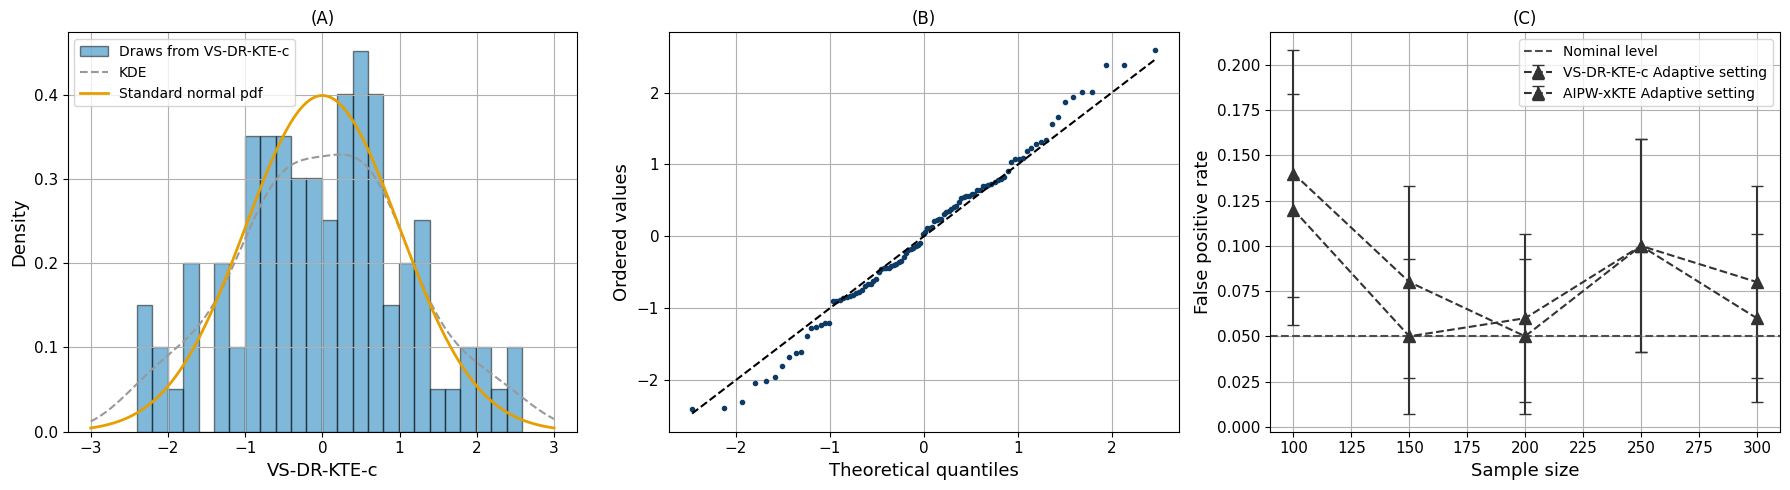

In [158]:
# Scenario I adaptive setting
name_folder_list_adaptive_null = ['debug_results/' + 'adaptive' + '/']
ns_list_false_null = ns_list
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['I']
# methods_false_null = ['VS-DR-KTE_alternating']
methods_false_null = ['VS-DR-KTE_chronological', 'DR-KTE_chronological']
case_list_false_null = [1]

d = dict()

for name_folder in name_folder_list_adaptive_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'debug_ns' + str(ns) + 'b' + str(b) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

store_results = 'plots'
os.makedirs(store_results, exist_ok=True)

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, gaussian_kde

# --- Styling (mimics your "sns-like" setup) ---
plt.rcParams["figure.figsize"] = (18, 5)
plt.rcParams["axes.grid"] = True
plt.rc("axes", labelsize=13)
plt.rc("xtick", labelsize=11)
plt.rc("ytick", labelsize=11)

# Colorblind-safe palette
cb_colors = {
    "hist": "#0072B2",     # blue
    "pdf": "#E69F00",      # orange
    "kde": "#999999",      # grey
    "qq": "#0D3B66",       # navy
    "nominal": "#4D4D4D"   # dark grey
}
# Per-method colors for panel (C)
method_colors = {
    "VS-DR-KTE": "#56B4E9",  # light blue
    "DR-xKTE":   "#009E73",  # green
    "IPW-xKTE":  "#CC79A7",  # pink
    "KTE":       "#F0E442"   # yellow (unused but available)
}
m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}
m_dict_title = {0: " Adaptive setting", 1: " Observational setting", 2:"Adaptive Setting"}
method_dict = {'VS-DR-KTE_alternating': 'VS-DR-KTE-a', 'VS-DR-KTE_chronological': 'VS-DR-KTE-c', 'DR-KTE_chronological': 'AIPW-xKTE', 'IPW-xKTE': 'IPW-xKTE', 'KTE': 'KTE'}

# --- Inputs matching your original snippet ---
case = 1
b = 'I'
ns = 300
# method = 'VS-DR-KTE_alternating'
method = 'VS-DR-KTE_chronological'
experiment = 'adaptive'
name_folder = f"debug_results/{experiment}/"
os.makedirs("plots", exist_ok=True)

# ===================== (A) HIST + KDE + NORMAL PDF =====================
plt.subplot(1, 3, 1)
fname = f"{name_folder}debug_ns{ns}b{b}{method}.csv"
stat_values = d[fname]['stat_values']
x_axis = np.linspace(-3, 3, 500)

# Histogram
plt.hist(
    stat_values,
    bins=25,
    density=True,
    color=cb_colors["hist"],
    alpha=0.5,
    edgecolor="black",
    label=f"Draws from {method_dict[method]}"
)

# KDE
kde = gaussian_kde(stat_values)
plt.plot(x_axis, kde(x_axis), linestyle="--", color=cb_colors["kde"], label="KDE")

# Standard Normal PDF
plt.plot(x_axis, norm.pdf(x_axis), linewidth=2, color=cb_colors["pdf"], label="Standard normal pdf")

plt.xlabel(method_dict[method])
plt.ylabel("Density")
plt.title("(A)")
plt.legend(loc="upper left")

# ============================== (B) QQ-PLOT ==============================
plt.subplot(1, 3, 2)
osm, osr = probplot(stat_values, dist="norm")[0]
plt.plot(osm, osr, marker='o', linestyle='', color=cb_colors["qq"], markersize=3)
plt.plot(osm, osm, color="black", linestyle="--")
plt.title("(B)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered values")

# ===== (C) FALSE POSITIVE RATE (multi-method) WITH ERROR BARS =====
plt.subplot(1, 3, 3)
confidence_level = 0.05
# method_list = ['VS-DR-KTE_alternating']
method_list = ['VS-DR-KTE_chronological', 'DR-KTE_chronological']

name_folder_list = [f"debug_results/{experiment}/"]
ns_array = np.array(ns_list)

for k, nf in enumerate(name_folder_list):
    for i, mth in enumerate(method_list):
        rejection_proportion = np.zeros(len(ns_list))
        n_per_file = None

        for j, ns_val in enumerate(ns_list):
            f = f"{nf}debug_ns{ns_val}b{b}{mth}.csv"
            pvals = d[f]['p_values']
            rejection_proportion[j] = (pvals < confidence_level).mean()
            n_per_file = len(pvals)  # assume constant across ns for varhat

        varhat = rejection_proportion * (1 - rejection_proportion) / n_per_file

        plt.errorbar(
            x=ns_array,
            y=rejection_proportion,
            yerr=1.96 * np.sqrt(varhat),
            capsize=4,
            marker=m_dict.get(k, "o"),
            markersize=8,
            color=method_colors.get(mth, "#333333"),
            linestyle='--',
            label=method_dict[mth] + m_dict_title[k]
        )

plt.axhline(confidence_level, color=cb_colors["nominal"], linestyle="--", label="Nominal level")
plt.title("(C)")
plt.xlabel("Sample size")
plt.ylabel("False positive rate")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:


def _precompute_fold_quadratics(KFF, R, Delta):
    KDelta = KFF @ Delta
    KR = KFF @ R
    v_dd = np.sum(Delta * (KFF @ Delta), axis=0)
    v_dr = np.sum(Delta * KR, axis=0)
    v_rr = np.sum(R * KR, axis=0)
    return v_dd, v_dr, v_rr, KDelta, KR


def _build_mu_R_Delta(KXX_fold, A_fold, lam):
    n = A_fold.size
    idx0 = np.where(A_fold == 0)[0]
    idx1 = np.where(A_fold == 1)[0]
    if idx0.size == 0 or idx1.size == 0:
        raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

    K00 = KXX_fold[np.ix_(idx0, idx0)]
    K11 = KXX_fold[np.ix_(idx1, idx1)]
    Kr0 = KXX_fold[:, idx0]  # K_{r,0}
    Kr1 = KXX_fold[:, idx1]  # K_{r,1}

    # Column selectors E0, E1 (place identity into the correct columns)
    E0 = np.zeros((idx0.size, n))
    E0[np.arange(idx0.size), idx0] = 1.0
    E1 = np.zeros((idx1.size, n))
    E1[np.arange(idx1.size), idx1] = 1.0

    mu0 = Kr0 @ np.linalg.solve(
        K00 + lam * np.eye(K00.shape[0]), E0
    )  # n×n, nonzero only at idx0 columns
    mu1 = Kr1 @ np.linalg.solve(
        K11 + lam * np.eye(K11.shape[0]), E1
    )  # n×n, nonzero only at idx1 columns

    mu = mu0 + mu1
    R = np.eye(n) - mu
    Delta = mu1 - mu0
    return R, Delta


# def _build_mu_R_Delta(KXX_fold, A_fold, lam):
#     n = A_fold.size
#     idx_control = np.where(A_fold == 0)[0]
#     idx_treated = np.where(A_fold == 1)[0]
#     if idx_control.size == 0 or idx_treated.size == 0:
#         raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

#     m_control, n_treated = idx_control.size, idx_treated.size
#     cols_perm = np.r_[idx_control, idx_treated]  # arm-stacked order

#     # Gram blocks in the chronological index system
#     K_cc = KXX_fold[np.ix_(idx_control, idx_control)]
#     K_ct = KXX_fold[np.ix_(idx_control, idx_treated)]
#     K_tc = KXX_fold[np.ix_(idx_treated, idx_control)]
#     K_tt = KXX_fold[np.ix_(idx_treated, idx_treated)]

#     # Dual operators on the arm-stacked column order [controls, treated]
#     mu0 = np.linalg.solve(K_cc + lam * np.eye(m_control), np.hstack([K_cc, K_ct]))
#     mu1 = np.linalg.solve(K_tt + lam * np.eye(n_treated), np.hstack([K_tc, K_tt]))

#     # Build μ in the ARM-STACKED row+col system first
#     mu_arm = np.zeros((n, n))
#     # rows: controls → mu0 ; treated → mu1 ; columns already arm-stacked
#     mu_arm[idx_control, :][:, cols_perm] = mu0
#     mu_arm[idx_treated, :][:, cols_perm] = mu1

#     mu_chrono = np.zeros((n, n))
#     mu_chrono[:, cols_perm] = mu_arm

#     # Split into μ̃1 and μ̃0 parts in chronological order
#     mu1_pad = np.zeros((n, n))
#     mu1_pad[idx_treated, :] = mu_chrono[idx_treated, :]
#     mu0_pad = np.zeros((n, n))
#     mu0_pad[idx_control, :] = mu_chrono[idx_control, :]

#     mu = mu0_pad + mu1_pad
#     R = np.eye(n) - mu
#     Delta = mu1_pad - mu0_pad
#     return R, Delta


# def _build_mu_R_Delta(KXX_fold, A_fold, lam):
#     """
#     Chronological KRR-based CME rows for each arm, no reordering, no padding.

#     Inputs:
#       - KXX_fold: (n×n) Gram on X within the fold, in chronological order.
#       - A_fold  : (n,) actions in the same chronological order.
#       - lam     : ridge parameter (λ).

#     Returns (all n×n, chronological-by-fold):
#       - R     = I - μ
#       - Delta = μ_1 - μ_0   with rows filled only for their own arm:
#                 rows of controls get  (- μ_0 rows), rows of treated get (+ μ_1 rows)
#     """
#     n = A_fold.size
#     idx_c = np.where(A_fold == 0)[0]
#     idx_t = np.where(A_fold == 1)[0]

#     if idx_c.size == 0 or idx_t.size == 0:
#         raise ValueError("A fold has no samples for one arm; cannot build Δ and R.")

#     # Blocks to *solve* (rows restricted to arm, columns = all, still chronological)
#     K_cc = KXX_fold[np.ix_(idx_c, idx_c)]
#     K_tt = KXX_fold[np.ix_(idx_t, idx_t)]
#     K_c_all = KXX_fold[np.ix_(idx_c, np.arange(n))]  # controls vs ALL cols (chrono)
#     K_t_all = KXX_fold[np.ix_(idx_t, np.arange(n))]  # treated  vs ALL cols (chrono)

#     # Solve Arm-wise ridge systems to get CME *rows* in chronological column order
#     # (K_aa + λI) * μ_a_rows = K_a,all  ⇒  μ_a_rows = (K_aa + λI)^{-1} K_a,all
#     try:
#         mu0_rows = np.linalg.solve(
#             K_cc + lam * np.eye(K_cc.shape[0]), K_c_all
#         )  # shape (m_c, n)
#     except np.linalg.LinAlgError:
#         mu0_rows = np.linalg.lstsq(
#             K_cc + lam * np.eye(K_cc.shape[0]), K_c_all, rcond=None
#         )[0]

#     try:
#         mu1_rows = np.linalg.solve(
#             K_tt + lam * np.eye(K_tt.shape[0]), K_t_all
#         )  # shape (m_t, n)
#     except np.linalg.LinAlgError:
#         mu1_rows = np.linalg.lstsq(
#             K_tt + lam * np.eye(K_tt.shape[0]), K_t_all, rcond=None
#         )[0]

#     # Assemble μ in *chronological* row+col system (no reindexing anywhere)
#     mu = np.zeros((n, n), dtype=KXX_fold.dtype)
#     mu[idx_c, :] = mu0_rows
#     mu[idx_t, :] = mu1_rows

#     # R and Δ in chronological order
#     R = np.eye(n, dtype=KXX_fold.dtype) - mu

#     Delta = np.zeros_like(mu)
#     # rows of controls carry -μ0; rows of treated carry +μ1
#     Delta[idx_c, :] = -mu0_rows
#     Delta[idx_t, :] = +mu1_rows

#     return R, Delta


def _fold_omegas(KFF, R, Delta, A_fold, w_fold, Pi_fold_on_fold):
    n = A_fold.size
    denom = np.where(A_fold == 0, 1.0 - w_fold, w_fold)
    v_dd, v_dr, v_rr, KDelta, KR = _precompute_fold_quadratics(KFF, R, Delta)

    omega = np.zeros(n, dtype=float)
    for t in range(n):
        p_t = Pi_fold_on_fold[t]
        s_t = np.where(A_fold == 0, -1.0 / (1.0 - p_t), 1.0 / p_t)
        num = np.where(A_fold == 0, 1.0 - p_t, p_t)
        rho = num / denom

        past_mask = (np.arange(n) < t).astype(float)
        S_size = int(past_mask.sum())
        if S_size == 0:
            omega[t] = 1
            continue

        u_t = (rho * past_mask) / S_size
        v_t = s_t * u_t

        q_diag = v_dd + 2.0 * s_t * v_dr + (s_t**2) * v_rr
        M2 = np.sum((rho * past_mask) * q_diag) / S_size

        z = Delta @ u_t
        q = R @ v_t
        Kz = KDelta @ u_t
        Kq = KR @ v_t
        M1_sq = z @ Kz + 2.0 * (z @ Kq) + q @ Kq

        var_t = M2 - M1_sq
        omega[t] = 0.0 if var_t <= 0.0 else 1.0 / np.sqrt(var_t)
    return omega


# def _fold_omegas(
#     KFF, R, Delta, A_fold, w_fold, Pi_fold_on_fold, clip_eps=1e-12, var_floor=1e-12
# ):
#     n = A_fold.size
#     w_fold = np.clip(w_fold, clip_eps, 1.0 - clip_eps)
#     denom = np.where(A_fold == 0, 1.0 - w_fold, w_fold)

#     KDelta = KFF @ Delta
#     KR = KFF @ R
#     v_dd = np.sum(Delta * KDelta, axis=0)
#     v_dr = np.sum(Delta * KR, axis=0)
#     v_rr = np.sum(R * KR, axis=0)

#     Pi_arr = np.asarray(Pi_fold_on_fold)
#     use_matrix = Pi_arr.ndim == 2 and Pi_arr.shape[0] >= n

#     omega = np.zeros(n, dtype=float)
#     ar = np.arange(n)

#     for t in range(n):
#         if use_matrix:
#             p_ts = np.clip(Pi_arr[t, :].reshape(-1), clip_eps, 1.0 - clip_eps)
#         else:
#             p_t = float(np.asarray(Pi_arr[t]).reshape(-1)[0])
#             p_ts = np.full(n, np.clip(p_t, clip_eps, 1.0 - clip_eps))

#         s_t = np.where(A_fold == 0, -1.0 / (1.0 - p_ts), 1.0 / p_ts)
#         num = np.where(A_fold == 0, 1.0 - p_ts, p_ts)
#         rho = num / denom

#         past = (ar < t).astype(float)
#         S = int(past.sum())
#         if S == 0:
#             omega[t] = np.nan  # we’ll drop these later
#             continue

#         u_t = (rho * past) / S
#         v_t = s_t * u_t

#         q_diag = v_dd + 2.0 * s_t * v_dr + (s_t**2) * v_rr
#         M2 = np.sum((rho * past) * q_diag) / S

#         z = Delta @ u_t
#         q = R @ v_t
#         Kz = KDelta @ u_t
#         Kq = KR @ v_t
#         M1_sq = z @ Kz + 2.0 * (z @ Kq) + q @ Kq

#         var_t = max(M2 - M1_sq, var_floor)
#         omega[t] = 1.0 / np.sqrt(var_t)

#     return omega


def xMMD2_vsdr_fold_generic(
    Y, w, X, A, kernel_function, Pi_0_on_0, Pi_1_on_1, idx0, idx1, lam=None, **kwargs
):
    Y = np.asarray(Y)
    Y = Y[:, None] if Y.ndim == 1 else Y
    X = np.asarray(X)
    X = X[:, None] if X.ndim == 1 else X
    A = np.asarray(A, int).ravel()
    w = np.asarray(w).ravel()

    # Split folds
    Y_split0, Y_split1 = Y[idx0], Y[idx1]
    X_split0, X_split1 = X[idx0], X[idx1]
    A_split0, A_split1 = A[idx0], A[idx1]
    w_split0, w_split1 = w[idx0], w[idx1]

    # Choose gamma from second fold (as before); lam defaults to gamma
    gamma = np.median(pairwise_distances(X_split1, X_split1, metric="euclidean")) ** 2
    if lam is None:
        lam = gamma

    # Covariate kernel within each fold
    KX0 = pairwise_kernels(X_split0, X_split0, metric="rbf", gamma=1.0 / gamma)
    KX1 = pairwise_kernels(X_split1, X_split1, metric="rbf", gamma=1.0 / gamma)

    # Dual-space R, Δ
    R0, Delta0 = _build_mu_R_Delta(KX0, A_split0, lam)
    R1, Delta1 = _build_mu_R_Delta(KX1, A_split1, lam)

    # Observed DR multipliers
    W_split0_obs = np.where(A_split0 == 0, -1.0 / (1.0 - w_split0), 1.0 / w_split0)
    W_split1_obs = np.where(A_split1 == 0, -1.0 / (1.0 - w_split1), 1.0 / w_split1)

    # DR operators
    M0 = Delta0 + R0 * W_split0_obs[None, :]
    M1 = Delta1 + R1 * W_split1_obs[None, :]

    # Outcome kernels
    K00 = pairwise_kernels(Y_split0, Y_split0, metric=kernel_function, **kwargs)
    K11 = pairwise_kernels(Y_split1, Y_split1, metric=kernel_function, **kwargs)
    K01 = pairwise_kernels(Y_split0, Y_split1, metric=kernel_function, **kwargs)

    # Cross matrix
    G0 = M0.T @ K01 @ M1

    # Variance stabilization weights
    omega_split0 = _fold_omegas(K00, R0, Delta0, A_split0, w_split0, Pi_0_on_0)
    omega_split1 = _fold_omegas(K11, R1, Delta1, A_split1, w_split1, Pi_1_on_1)

    # # Stabilize + normalize
    # G = G0 / (omega_split0[:, None] * omega_split1[None, :] + 1e-12)

    valid0 = np.isfinite(omega_split0) & (omega_split0 > 0)
    valid1 = np.isfinite(omega_split1) & (omega_split1 > 0)
    if not np.any(valid0) or not np.any(valid1):
        raise ValueError(
            "No valid indices after filtering stabilizers (check Π alignment)."
        )

    G0 = G0[np.ix_(valid0, valid1)]
    omega0 = omega_split0[valid0]
    omega1 = omega_split1[valid1]

    # then do the stabilization with only valid rows/cols (no +1e-12 needed):
    G = G0 / (omega0[:, None] * omega1[None, :])

    # S = np.mean(G)
    # psi_cross_hat = np.mean(G**2)

    # T_stat = np.sqrt(G.shape[0] * G.shape[1]) * S / np.sqrt(psi_cross_hat + 1e-12)
    # return float(T_stat)

    S = np.mean(G)
    psi_cross_hat = np.mean(G**2)
    T_stat = S / np.sqrt(psi_cross_hat + 1e-12)
    return float(T_stat)